In [2]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up paths
data_dir = Path("../data")
roi_file = data_dir / "roi.json"
image_file = data_dir / "media/SiteA.jpg"

# Load ROI data
with open(roi_file, 'r') as f:
    roi_data = json.load(f)

# Load the image
image = cv2.imread(str(image_file))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Image shape: {image_rgb.shape}")
print(f"ROI data loaded for: {list(roi_data.keys())}")


Image shape: (2160, 3840, 3)
ROI data loaded for: ['Site A']


In [3]:
# Extract Site A ROI coordinates
site_a_rois = roi_data["Site A"]["A"]

# Create a copy of the image for visualization
vis_image = image_rgb.copy()

# Define colors for different ROI regions (in RGB)
colors = [
    (255, 0, 0),      # Red
    (0, 255, 0),      # Green
    (0, 0, 255),      # Blue
    (255, 255, 0),    # Yellow
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Cyan
]

# Draw each ROI polygon
for idx, (roi_id, coords) in enumerate(site_a_rois.items()):
    # Convert coordinates to numpy array
    pts = np.array(coords, dtype=np.int32)
    
    # Get color for this ROI
    color = colors[idx % len(colors)]
    
    # Draw filled polygon with transparency
    overlay = vis_image.copy()
    cv2.fillPoly(overlay, [pts], color)
    cv2.addWeighted(overlay, 0.3, vis_image, 0.7, 0, vis_image)
    
    # Draw polygon outline
    cv2.polylines(vis_image, [pts], isClosed=True, color=color, thickness=3)
    
    # Add ROI label
    centroid = pts.mean(axis=0).astype(int)
    cv2.putText(vis_image, f"ROI {roi_id}", tuple(centroid), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)
    
    # Draw vertices as circles
    for point in coords:
        cv2.circle(vis_image, tuple(point), 8, color, -1)

print(f"Plotted {len(site_a_rois)} ROI regions")


Plotted 6 ROI regions


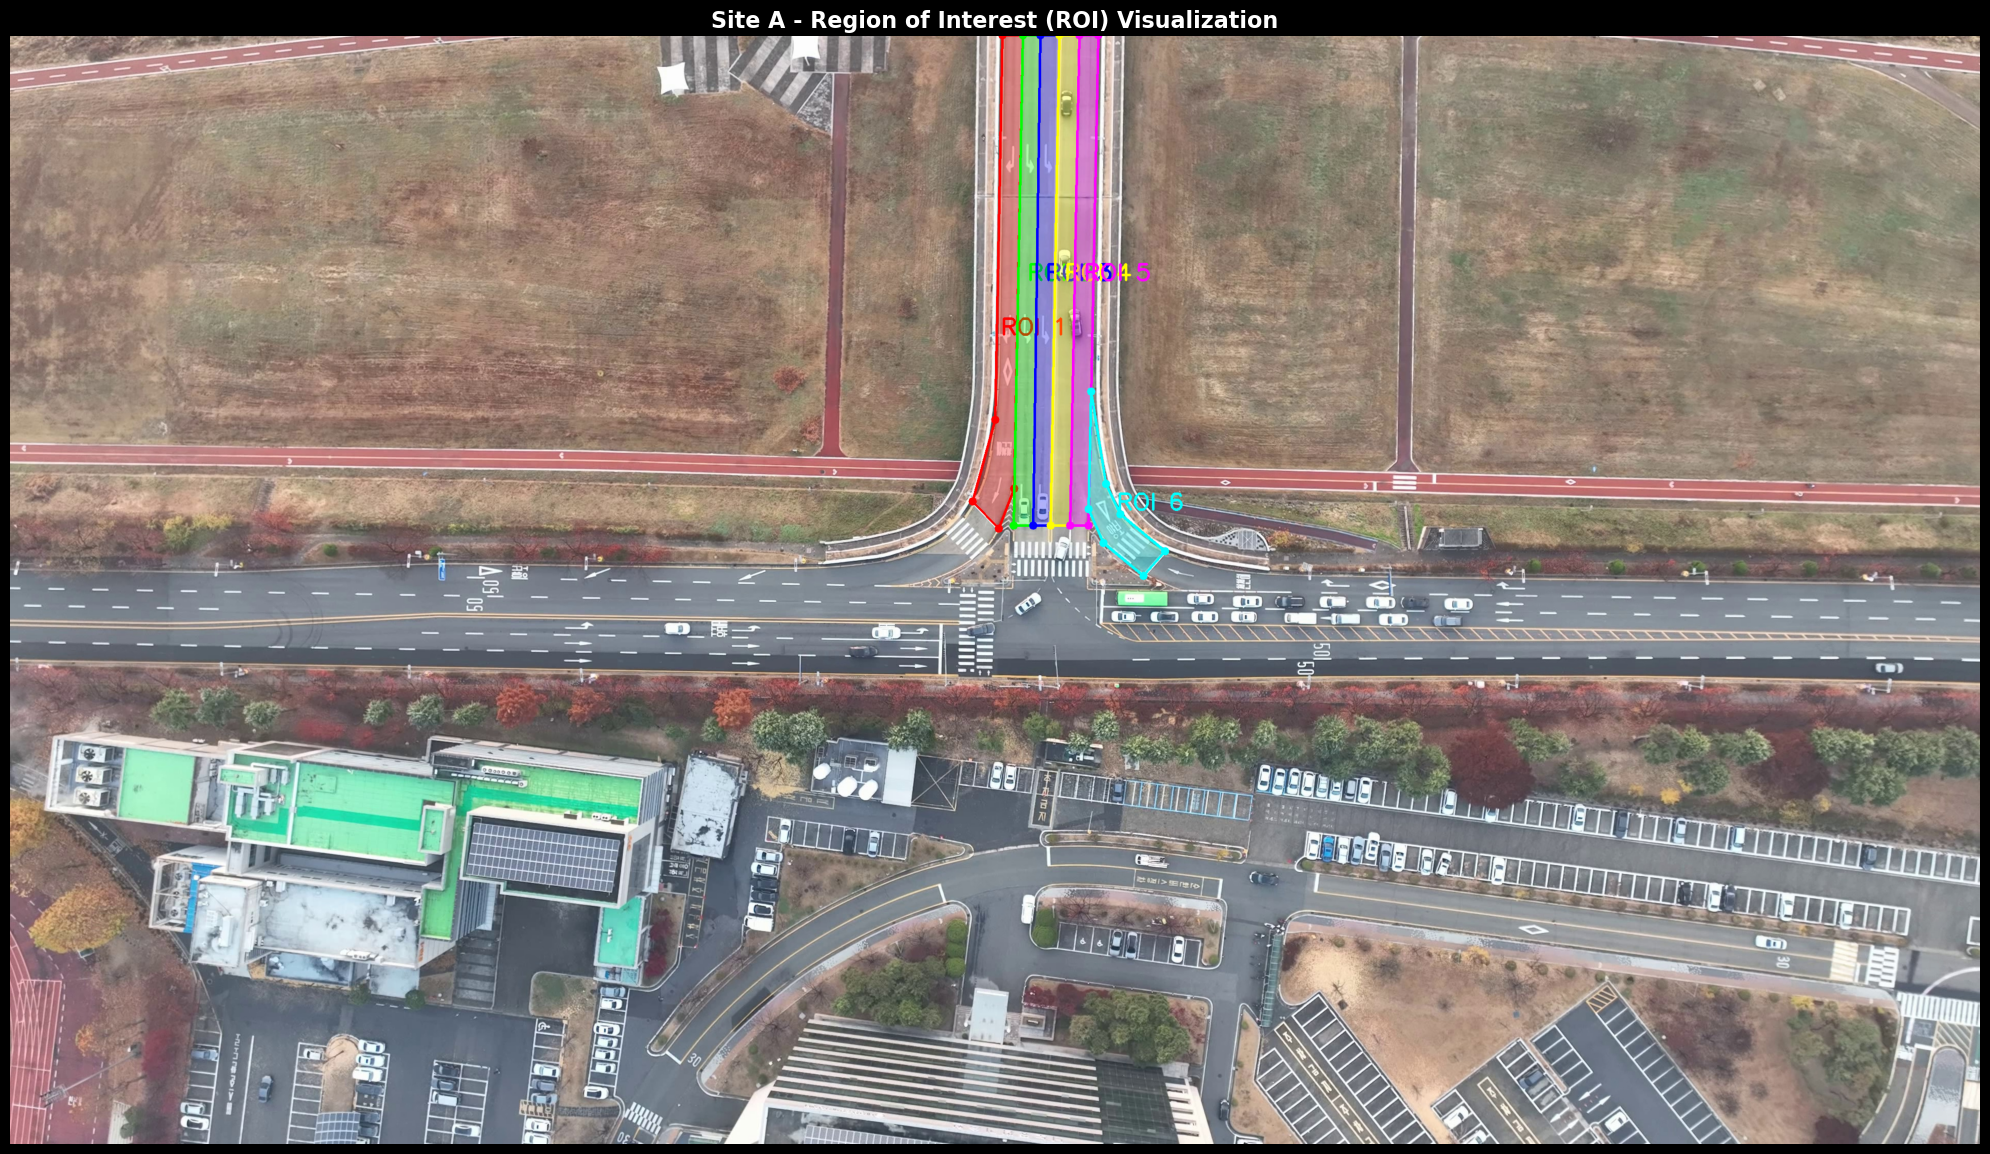

In [4]:
# Display the image with ROI annotations
plt.figure(figsize=(20, 12))
plt.imshow(vis_image)
plt.title("Site A - Region of Interest (ROI) Visualization", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Print detailed ROI information
print("ROI Coordinate Details:")
print("=" * 50)
for roi_id, coords in site_a_rois.items():
    print(f"\nROI {roi_id}:")
    print(f"  Number of vertices: {len(coords)}")
    print(f"  Coordinates: {coords}")
